## The Testing Script:
I've made this Single-Cell script for your testing convenience. This script tests the predictions of the trained Model while also mimicking a simplified version of what the training script does and visualizes it for you to see what's going on underneath all the mathematics.


###Notes and Tips for Dr. Mirza:
Al-Salam Alaykum Dr. Mirza, I hope you're doing well. I strongly recommend reading this text before proceeding for your convenience to avoid any problems. Some of these things mentioned here are just a re-iteration of what I've already stated in the ReadMe.md file but with a few more details and a slightly less formal language to make things feel a bit more relaxed.
<br><br>
-1) As mentioned in the README file, I've made this script so that you would not have to run the entire model training script as there are some cells in that script that take a considerable amount of time to run. I estimate that it may take you at least 75 minutes to run the training script entirely.
<br><br>
-2) To use this script, all you need is to temporarily place the sample testing images provided in the "Test Images" folder and the model (.pkl) file itself inside the runtime's temporary contents files. You can simply drag and drop them. At the very top of the cell, there are 5 "sample_img_path" declarations for 5 different classes. Simply uncomment the image path you wish to test.
<br><br>
-3) Honestly, Google Colab is Notoriously slow at loading large files into the contents file when they have been downloaded locally. <strong> This script will NOT run and will cause errors UNLESS you fully wait for the model (.pkl) file to fully load into the contents. The progress of this loading can be seen on the bottom left in the form of a circle. To be honest, this will likely take a very long time since the model file is of size 800MB. So, in the meantime, I do recommend checking out the work of other students.</strong>
<br><br>
-4) In the worst case scenario if this does take too long for your liking, I have made sure that this Notebook is saved while displaying the results of a test run that I've made. So, you can check the results of that run instead.
<br><br>
-5) As explained in the documentation and README file, this model achieves an accuracy of 80%, and the confusion matrix of each class was provided. Naturally, not every test prediction is going to be right.

Loading Model from final_plant_disease_model.pkl...

>>> DIAGNOSIS COMPLETED.
>>> PREDICTION: GRAPE___LEAF_BLIGHT_(ISARIOPSIS_LEAF_SPOT)


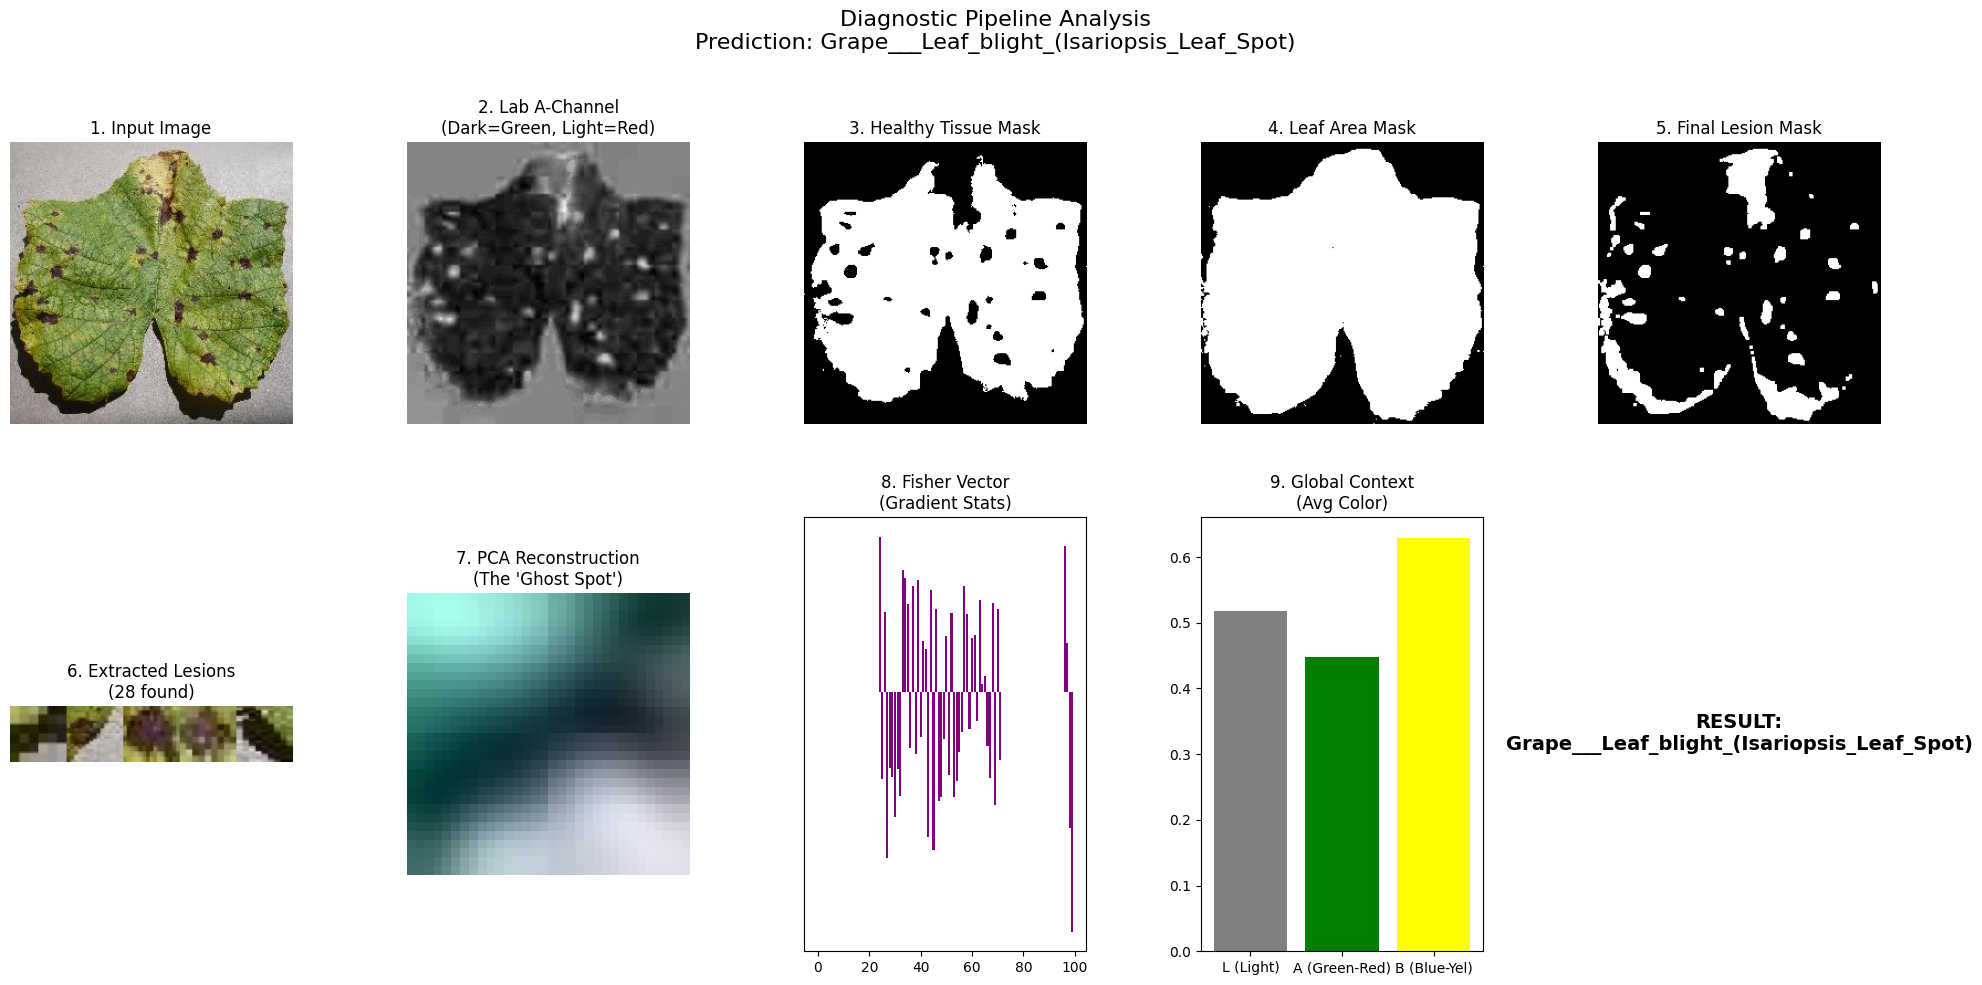

In [8]:
import pickle
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

#********** Configurations **********

# REPLACE THIS PATH with the image you want to test
#sample_img_path = "/content/Apple_Black_rot.jpeg"
#sample_img_path = "/content/Corn_Cercospora_leaf_spot Gray_leaf_spot.jpeg"
sample_img_path = "/content/Grape_Leaf_blight_(Isariopsis_Leaf_Spot).jpeg"
#sample_img_path = "/content/Soybean_Healthy.jpeg"
#sample_img_path = "/content/Squash_PowderyMildew.jpeg"

MODEL_PATH = 'final_plant_disease_model.pkl'

#********** Utilities **********

def fisher_vector(xx, gmm):
    """Computes the Fisher Vector (Gradient Statistics)"""
    xx = np.atleast_2d(xx)
    Q = gmm.predict_proba(xx)
    Q_sum = np.sum(Q, 0)[:, np.newaxis]
    Q_xx = np.dot(Q.T, xx)
    Q_xx_2 = np.dot(Q.T, xx ** 2)
    means = gmm.means_
    sigmas = gmm.covariances_
    weights = gmm.weights_
    d_mu = (Q_xx - Q_sum * means) / np.sqrt(weights[:, np.newaxis] * sigmas)
    d_sigma = (Q_xx_2 - 2 * Q_xx * means + Q_sum * means**2 - Q_sum * sigmas) / np.sqrt(2 * weights[:, np.newaxis] * sigmas**2)
    return np.hstack((d_mu.flatten(), d_sigma.flatten()))

def extract_global_features_explicit(img):
    """Extracts Global Color Context (Mean/Std of Lab)"""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = hsv[:,:,1] > 25 # Saturation mask
    if np.sum(mask) == 0: return np.zeros(6)
    return np.array([np.mean(l[mask]), np.mean(a[mask]), np.mean(b[mask]),
                     np.std(l[mask]), np.std(a[mask]), np.std(b[mask])]) / 255.0

#********** Execution Pipeline **********

# 1. Load Model
print(f"Loading Model from {MODEL_PATH}...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("Model file not found! Please upload 'final_plant_disease_model.pkl'")

with open(MODEL_PATH, 'rb') as f:
    saved_data = pickle.load(f)

pca = saved_data['pca']
gmm = saved_data['gmm']
svm = saved_data['svm']

# 2. Load and Preprocess Image
if not os.path.exists(sample_img_path):
    print(f"Warning: Image {sample_img_path} not found. Using a dummy black image.")
    img = np.zeros((256,256,3), dtype=np.uint8)
else:
    img = cv2.imread(sample_img_path)
    img = cv2.resize(img, (256, 256))

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# STEP A: Segmentation Logic
# 1. Convert to LAB (Because the A channel is very valuable to our cause)
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv2.split(lab)

# 2. Green Mask (A-Channel Threshold)
# In OpenCV, A < 120 is generally Green (In general, Green-ness in the LAB system is negative, but in OpenCV, it's given by values less than 120)
_, green_mask = cv2.threshold(a_channel, 120, 255, cv2.THRESH_BINARY_INV)

# 3. Leaf Area Mask (Saturation Threshold to get rid of background)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
s_channel = hsv[:,:,1]
_, leaf_area_mask = cv2.threshold(s_channel, 25, 255, cv2.THRESH_BINARY)

# 4. Combine: Disease = (Not Green) AND (Is Leaf)
# By the way, we invert green_mask to get "Not Green"
not_green = cv2.bitwise_not(green_mask)
disease_mask_raw = cv2.bitwise_and(not_green, leaf_area_mask)

# 5. Clean Up (Morphology)
kernel = np.ones((3,3), np.uint8)
disease_mask_clean = cv2.morphologyEx(disease_mask_raw, cv2.MORPH_OPEN, kernel, iterations=1)

# STEP B: Spot Extraction:
contours, _ = cv2.findContours(disease_mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lesion_crops = []
lesion_vectors = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if 10 < area < 1000: # Filter Noise
        x, y, w, h = cv2.boundingRect(cnt)
        roi = img[y:y+h, x:x+w]
        try:
            # Resize to 32x32 for PCA
            roi_resized = cv2.resize(roi, (32, 32), interpolation=cv2.INTER_AREA)
            lesion_crops.append(roi_resized)
            lesion_vectors.append(roi_resized.flatten())
        except: pass

# STEP C & D: Encoding & Classification:
# Initialize Feature Vector
fv_dim = 2 * 64 * 24 # 2 * K * D
final_fv = np.zeros(fv_dim)

if len(lesion_vectors) > 0:
    # 1. Project to Eigen-Lesions (PCA)
    pca_proj = pca.transform(lesion_vectors)

    # 2. Encode Gradient Statistics (Fisher Vector)
    final_fv = fisher_vector(pca_proj, gmm)

    # 3. Normalize (Power + L2)
    final_fv = np.sign(final_fv) * np.sqrt(np.abs(final_fv))
    norm = np.linalg.norm(final_fv)
    if norm > 0: final_fv = final_fv / norm

# 4. Add Global Context (Color)
global_color = extract_global_features_explicit(img)
final_combined_vector = np.hstack([final_fv, global_color * 3.0]) # Weighting x3

# 5. Predict
prediction_idx = svm.predict([final_combined_vector])[0]
prediction_text = str(prediction_idx)

print(f"\n>>> DIAGNOSIS COMPLETED.")
print(f">>> PREDICTION: {prediction_text.upper()}")

#********** VISUALIZATION **********

plt.figure(figsize=(20, 10))
plt.suptitle(f"Diagnostic Pipeline Analysis\nPrediction: {prediction_text}", fontsize=16)

# Row 1: The Segmentation
plt.subplot(2, 5, 1); plt.imshow(rgb_img); plt.title("1. Input Image"); plt.axis('off')
plt.subplot(2, 5, 2); plt.imshow(a_channel, cmap='gray'); plt.title("2. Lab A-Channel\n(Dark=Green, Light=Red)"); plt.axis('off')
plt.subplot(2, 5, 3); plt.imshow(green_mask, cmap='gray'); plt.title("3. Healthy Tissue Mask"); plt.axis('off')
plt.subplot(2, 5, 4); plt.imshow(leaf_area_mask, cmap='gray'); plt.title("4. Leaf Area Mask"); plt.axis('off')
plt.subplot(2, 5, 5); plt.imshow(disease_mask_clean, cmap='gray'); plt.title("5. Final Lesion Mask"); plt.axis('off')

# Row 2: The Analysis
# 6. Extracted Spots
plt.subplot(2, 5, 6)
if len(lesion_crops) > 0:
    # Show first 5 spots stacked
    show_n = min(len(lesion_crops), 5)
    collage = np.hstack([cv2.cvtColor(lesion_crops[i], cv2.COLOR_BGR2RGB) for i in range(show_n)])
    plt.imshow(collage)
    plt.title(f"6. Extracted Lesions\n({len(lesion_crops)} found)")
else:
    plt.text(0.5, 0.5, "No Spots Found", ha='center')
plt.axis('off')

# 7. Eigen-Lesion Reconstruction (What the PCA sees)
plt.subplot(2, 5, 7)
if len(lesion_vectors) > 0:
    # Reconstruct the first spot from PCA components
    recon_vec = pca.inverse_transform(pca_proj[0])
    recon_img = recon_vec.reshape(32, 32, 3)
    recon_img = (recon_img - recon_img.min()) / (recon_img.max() - recon_img.min())
    plt.imshow(recon_img)
    plt.title("7. PCA Reconstruction\n(The 'Ghost Spot')")
else:
    plt.text(0.5, 0.5, "N/A", ha='center')
plt.axis('off')

# 8. Fisher Vector
plt.subplot(2, 5, 8)
# Show first 100 dims
plt.bar(range(100), final_fv[:100], color='purple')
plt.title("8. Fisher Vector\n(Gradient Stats)")
plt.yticks([])

# 9. Global Color Context
plt.subplot(2, 5, 9)
colors = ['L (Light)', 'A (Green-Red)', 'B (Blue-Yel)']
plt.bar(colors, global_color[:3], color=['gray', 'green', 'yellow'])
plt.title("9. Global Context\n(Avg Color)")

# 10. Final Result
plt.subplot(2, 5, 10)
plt.text(0.5, 0.5, f"RESULT:\n{prediction_text}", ha='center', va='center', fontsize=14, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('pipeline_analysis.png')
plt.show()